<div style="font-family:'Times New Roman';">

En este ejemplo, recuperaremos un espectro y lo visualizaremos, de forma similar al ejemplo 2. Sin embargo, no leeremos el espectro de un archivo, sino que lo recuperaremos directamente de un repositorio en línea. También usaremos Pyteomics para anotar fragmentos de iones. ¡Comencemos! El código completo se puede descargar here.

Necesitaremos spectrum_utils , una biblioteca para el procesamiento y visualización del espectro. Pyteomics se integra con ella y permite crear fácilmente gráficos de espectro anotados.

Primero, usamos el Identificador Universal de Espectro de un espectro para descargarlo directamente del repositorio MassIVE . Pyteomics proporciona herramientas para ello en el pyteomics.usimódulo.

In [8]:
from pyteomics import pylab_aux as pa, usi
import matplotlib.pyplot as plt
spectrum = usi.proxi(
    'mzspec:PXD004732:01650b_BC2-TUM_first_pool_53_01_01-3xHCD-1h-R2:scan:41840',
    'massive')
peptide = 'WNQLQAFWGTGK'

<div style="font-family:'Times New Roman';">

A continuación, simplemente trace el espectro y anótelo con una sola llamada de función:

Verá una anotación spectrum_utils simple del espectro:



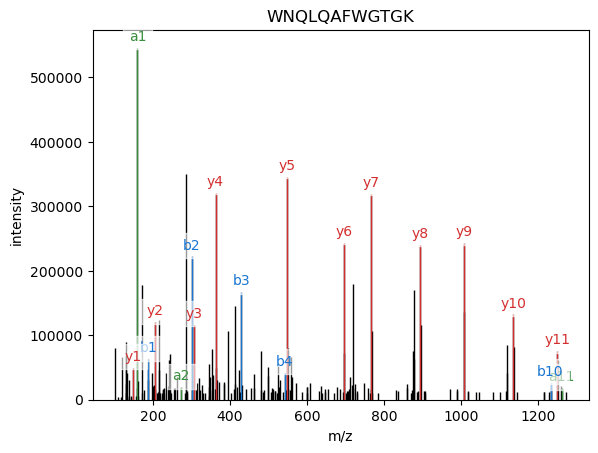

In [9]:
pa.annotate_spectrum(spectrum, peptide, precursor_charge=2, backend='default', ion_types='aby', title=peptide)
plt.show()

<div style="font-family:'Times New Roman';">


pyteomics.pylab_aux.annotate_spectrum()acepta una serie de parámetros de palabras clave, lo que le permite hacer casi todo lo que puede hacer con spectrum_utils.

Spectrum_utils también permite crear gráficos espejo. Siguiendo la documentación de Spectrum_utils , haremos esta parte más compleja, mostrando más posibilidades. Este ejemplo incluye péptidos modificados y un poco de preprocesamiento del espectro. Además, en esta ocasión, usaremos el backend spectrum_utils.iplot para generar un gráfico interactivo .

Para anotar el espectro de un péptido modificado, puede usar la notación ProForma , que es el único formato compatible con spectrum_utils actualmente. También puede usar la notación modX, estándar en Pyteomics: se convertirá a ProForma si es posible.

In [10]:
from pyteomics import mass
peptide = 'DLTDYLoxMK'  # oxidized methionine
aa_mass = mass.std_aa_mass.copy()
aa_mass['ox'] = 15.9949  # define the mass of the label

<div style="font-family:'Times New Roman';">

**Nota**

En este caso, utilizando aa_mass y la secuencia modX , Pyteomics la convertirá en una cadena ProForma usando pyteomics.parser.to_proforma():

from pyteomics import parser
parser.to_proforma(peptide, aa_mass=aa_mass)
'DLTDYLM[+15.9949]K'

<div style="font-family:'Times New Roman';">

¡Volviendo a nuestro guion! A continuación, elegimos dos espectros:



In [11]:
usi_top = 'mzspec:MSV000079960:DY_HS_Exp7-Ad1:scan:30372'
usi_bottom = 'mzspec:MSV000080679:j11962_C1orf144:scan:10671'

spectrum_top = usi.proxi(usi_top, 'massive')
spectrum_bottom = usi.proxi(usi_bottom, 'massive')

<div style="font-family:'Times New Roman';">

Y por último, produce la imagen con:



In [20]:
pa.mirror(spectrum_top, spectrum_bottom, peptide=peptide, precursor_charge=2,
    aa_mass=aa_mass, ion_types='aby', ftol=0.5, scaling='root',
    remove_precursor_peak=True, backend='spectrum_utils.iplot'
    ).properties(width=640, height=400).save('mirror.html')